In [58]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

True

In [59]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [60]:
# defining the max tokens
MAX_TOKENS = 50

In [61]:
def chat_node_trimmer(state: MessagesState):

    #triming before calling the messages

    messages = trim_messages(
        state['messages'],
        strategy='last', 
        token_counter=count_tokens_approximately, 
        max_tokens=MAX_TOKENS)
    
    print("Number of tokens in the messages:", count_tokens_approximately(messages=messages))
    
    # for printing the messages
    for message in messages:
        print(message.content)
        
    response = LLM.invoke(messages)
    return {'messages': [response]}

In [62]:
# building the graph
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node_trimmer)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

memory = InMemorySaver()
Triming_STM = graph.compile(checkpointer=memory)

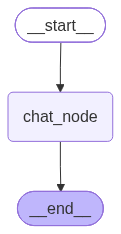

In [63]:
from IPython.display import Image
Image(Triming_STM.get_graph().draw_mermaid_png())

In [64]:
#creating the thread id for the chat
config1 = {"configurable": {"thread_id": "chat-2"}}

In [65]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hi"}]}, config=config1)
result['messages'][-1].content

Number of tokens in the messages: 5
hi


'Hello! How can I help you today?'

In [66]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "i am learning about langgraph"}]}, config=config1)
result['messages'][-1].content

Number of tokens in the messages: 31
hi
Hello! How can I help you today?
i am learning about langgraph


'That’s great! LangGraph is a powerful library for building composable, state‑driven workflows (often called “graphs”) on top of language models. It lets you define nodes (functions, prompts, or other agents) and edges (the logic that decides where to go next) so you can create complex, multi‑step interactions while keeping the overall flow easy to reason about.\n\nBelow is a quick primer to get you started, plus some resources and tips for deeper exploration.\n\n---\n\n## 1️⃣ What’s the Core Idea?\n\n| Concept | What it means in LangGraph | Typical use‑case |\n|---------|---------------------------|-----------------|\n| **Node** | A callable (function, LangChain chain, LLM prompt, etc.) that receives the current **state** and returns an updated state (and optionally an output). | “Ask the user for their name”, “Call an external API”, “Generate a summary”. |\n| **Edge** | The routing logic that decides which node to execute next based on the current state. It can be a simple condition,

In [67]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "can you write a 10 line paragraph on langgraph?"}]},config=config1)
result["messages"][-1].content

Number of tokens in the messages: 16
can you write a 10 line paragraph on langgraph?


'LangGraph is an open‑source Python library that lets developers construct LLM‑driven applications as directed graphs of modular nodes.  \nEach node encapsulates a specific task—such as prompting, tool use, or state management—making the overall workflow transparent and reusable.  \nThe framework builds on LangChain’s abstractions, extending them with explicit graph semantics and built‑in support for branching, looping, and conditional execution.  \nBy representing logic as a graph, LangGraph enables visual debugging and easier reasoning about complex conversational flows.  \nState is passed along edges, allowing seamless context propagation without manual bookkeeping.  \nDevelopers can plug in custom LLMs, APIs, or external tools as nodes, creating hybrid pipelines that blend generative AI with deterministic services.  \nThe library includes utilities for serialization, checkpointing, and resuming long‑running processes, which is crucial for production‑grade deployments.  \nLangGraph’

In [68]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hello how are you what are you doing can you name good leetcode algorithms for my interview tomorrow?"}]}, config1)
result["messages"][-1].content

Number of tokens in the messages: 30
hello how are you what are you doing can you name good leetcode algorithms for my interview tomorrow?


'Hey there! I’m doing great—thanks for asking. Good luck with your interview tomorrow! Below is a quick cheat‑sheet of the most frequently‑tested algorithmic topics on LeetCode (and similar platforms) along with a few “must‑solve” problems for each category. Feel free to pick the ones that match the role you’re targeting (e.g., software engineering, data‑science, system design) and the time you have left to study.\n\n---\n\n## 1️⃣ Array & String Manipulation\n| Core Idea | Typical Problems | Example LeetCode IDs |\n|-----------|------------------|----------------------|\n| Two‑pointer sliding window | Longest substring without repeating characters, Minimum size subarray sum | 3, 76, 209 |\n| Prefix sums & hash‑map | Subarray sum equals K, Subarray with maximum sum | 560, 560 (same), 523 |\n| In‑place reversal / rotation | Rotate array, Reverse words in a string | 189, 151, 344 |\n| Frequency counting | Top K frequent elements, Group anagrams | 347, 49, 49 |\n\n**Quick practice:**  \n- 